# DDRI bike_change full161 정제 패턴 비교 근거 노트북

목적: 정제 전후의 시간 패턴이 어떻게 달라지는지 차트로 남겨, `bike_change_deseasonalized` 사용 근거를 문서화한다.

이 노트북은 아래를 비교한다.
- `rental_count`
- `bike_change_raw`
- `bike_change_deseasonalized`

핵심 질문:
1. `station_id + weekday + hour` 기준 반복 패턴이 실제로 강한가
2. Train 2023 기준 seasonal mean 제거 후 주간 반복 패턴이 약해지는가
3. 정제 전후 분포와 대여소별 시간 패턴이 어떻게 바뀌는가


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display, Image

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

root_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
work_dir = None
for base in root_candidates:
    candidate = (base / 'works' / '08_prediction_bike_change_full161_base').resolve()
    if candidate.exists():
        work_dir = candidate
        break

if work_dir is None:
    raise FileNotFoundError('works/08_prediction_bike_change_full161_base 경로를 찾지 못했습니다.')

output_data_dir = work_dir / 'output' / 'data'
output_report_dir = work_dir / 'output' / 'reports'
evidence_dir = work_dir / 'output' / 'evidence'
evidence_dir.mkdir(parents=True, exist_ok=True)

train_path = output_data_dir / 'ddri_prediction_bike_change_full161_base_train_2023_2024.csv'
test_path = output_data_dir / 'ddri_prediction_bike_change_full161_base_test_2025.csv'
meta_path = output_report_dir / 'ddri_prediction_bike_change_full161_base_feature_meta.json'

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError('정제 데이터가 아직 없습니다. 02 노트북 또는 dataset_builder.py를 먼저 실행해 주세요.')

train_df = pd.read_csv(train_path, parse_dates=['date'])
test_df = pd.read_csv(test_path, parse_dates=['date'])
meta = json.loads(meta_path.read_text(encoding='utf-8')) if meta_path.exists() else {}

train_2023 = train_df[train_df['date'] < '2024-01-01'].copy()
valid_2024 = train_df[train_df['date'] >= '2024-01-01'].copy()

display(Markdown(f"### 데이터 크기\n- train_full: `{len(train_df):,}`\n- train_2023: `{len(train_2023):,}`\n- validation_2024: `{len(valid_2024):,}`\n- test_2025: `{len(test_df):,}`"))
display(Markdown(f"### 정제 메타\n```json\n{json.dumps(meta, ensure_ascii=False, indent=2)}\n```"))


### 데이터 크기
- train_full: `2,824,423`
- train_2023: `1,410,199`
- validation_2024: `1,414,224`
- test_2025: `1,410,199`

### 정제 메타
```json
{
  "train_source": "/Users/cheng80/Desktop/ddri_work/3조 공유폴더/군집별 데이터_전체 스테이션/full_data/ddri_prediction_long_train_2023_2024.csv",
  "test_source": "/Users/cheng80/Desktop/ddri_work/3조 공유폴더/군집별 데이터_전체 스테이션/full_data/ddri_prediction_long_test_2025.csv",
  "train_output": "/Users/cheng80/Desktop/ddri_work/works/08_prediction_bike_change_full161_base/output/data/ddri_prediction_bike_change_full161_base_train_2023_2024.csv",
  "test_output": "/Users/cheng80/Desktop/ddri_work/works/08_prediction_bike_change_full161_base/output/data/ddri_prediction_bike_change_full161_base_test_2025.csv",
  "feature_summary_output": "/Users/cheng80/Desktop/ddri_work/works/08_prediction_bike_change_full161_base/output/data/ddri_prediction_bike_change_full161_base_feature_summary.csv",
  "base_features": [
    "station_id",
    "cluster",
    "mapped_dong_code",
    "hour",
    "weekday",
    "month",
    "holiday",
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed"
  ],
  "target_columns": [
    "bike_change_raw",
    "seasonal_mean_train_2023",
    "bike_change_deseasonalized"
  ],
  "train_rows_after_target": 2824423,
  "test_rows_after_target": 1410199,
  "train_unique_stations": 161,
  "test_unique_stations": 161,
  "seasonal_groups_from_train_2023": 27048,
  "policy": {
    "train": "2023",
    "validation": "2024",
    "test": "2025",
    "refit": "validation 우세 모델 선택 후 2023+2024 재학습 -> 2025 평가"
  }
}
```

In [2]:
def heatmap_df(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return df.groupby(['weekday', 'hour'])[value_col].mean().unstack('hour').reindex(index=range(7), columns=range(24))

def station_heatmap_df(df: pd.DataFrame, station_id: int, value_col: str) -> pd.DataFrame:
    sub = df[df['station_id'] == station_id].copy()
    return sub.groupby(['weekday', 'hour'])[value_col].mean().unstack('hour').reindex(index=range(7), columns=range(24))

def save_heatmap(matrix: pd.DataFrame, title: str, out_path: Path, cmap: str = 'coolwarm', center=None):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    im = ax.imshow(matrix.values, aspect='auto', cmap=cmap)
    if center is not None:
        vmax = np.nanmax(np.abs(matrix.values))
        im.set_clim(-vmax, vmax)
    ax.set_title(title)
    ax.set_xlabel('hour')
    ax.set_ylabel('weekday')
    ax.set_xticks(range(24))
    ax.set_yticks(range(7))
    ax.set_yticklabels(['Mon?0','Tue?1','Wed?2','Thu?3','Fri?4','Sat?5','Sun?6'])
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('mean value')
    fig.tight_layout()
    fig.savefig(out_path, dpi=170)
    plt.close(fig)

def save_overlay_by_hour(df: pd.DataFrame, station_id: int, out_path: Path):
    sub = df[df['station_id'] == station_id].copy()
    summary = sub.groupby('hour')[['rental_count', 'bike_change_raw', 'bike_change_deseasonalized']].mean().reindex(range(24))
    fig, ax1 = plt.subplots(figsize=(12, 4.5))
    ax1.plot(summary.index, summary['rental_count'], color='#1f77b4', marker='o', label='rental_count mean')
    ax1.set_xlabel('hour')
    ax1.set_ylabel('rental_count mean', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    ax2.plot(summary.index, summary['bike_change_raw'], color='#d62728', marker='s', label='bike_change_raw mean')
    ax2.plot(summary.index, summary['bike_change_deseasonalized'], color='#2ca02c', marker='^', label='bike_change_deseasonalized mean')
    ax2.set_ylabel('bike_change mean', color='#333333')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title(f'station {station_id} hour pattern comparison')
    fig.tight_layout()
    fig.savefig(out_path, dpi=170)
    plt.close(fig)

def save_distribution_compare(df: pd.DataFrame, out_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].hist(df['bike_change_raw'], bins=80, color='#d62728', alpha=0.8)
    axes[0].set_title('bike_change_raw distribution')
    axes[1].hist(df['bike_change_deseasonalized'], bins=80, color='#2ca02c', alpha=0.8)
    axes[1].set_title('bike_change_deseasonalized distribution')
    for ax in axes:
        ax.set_xlabel('value')
        ax.set_ylabel('count')
    fig.tight_layout()
    fig.savefig(out_path, dpi=170)
    plt.close(fig)


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


### 저장된 전체 heatmap

#### 01_train2023_rental_count_heatmap.png

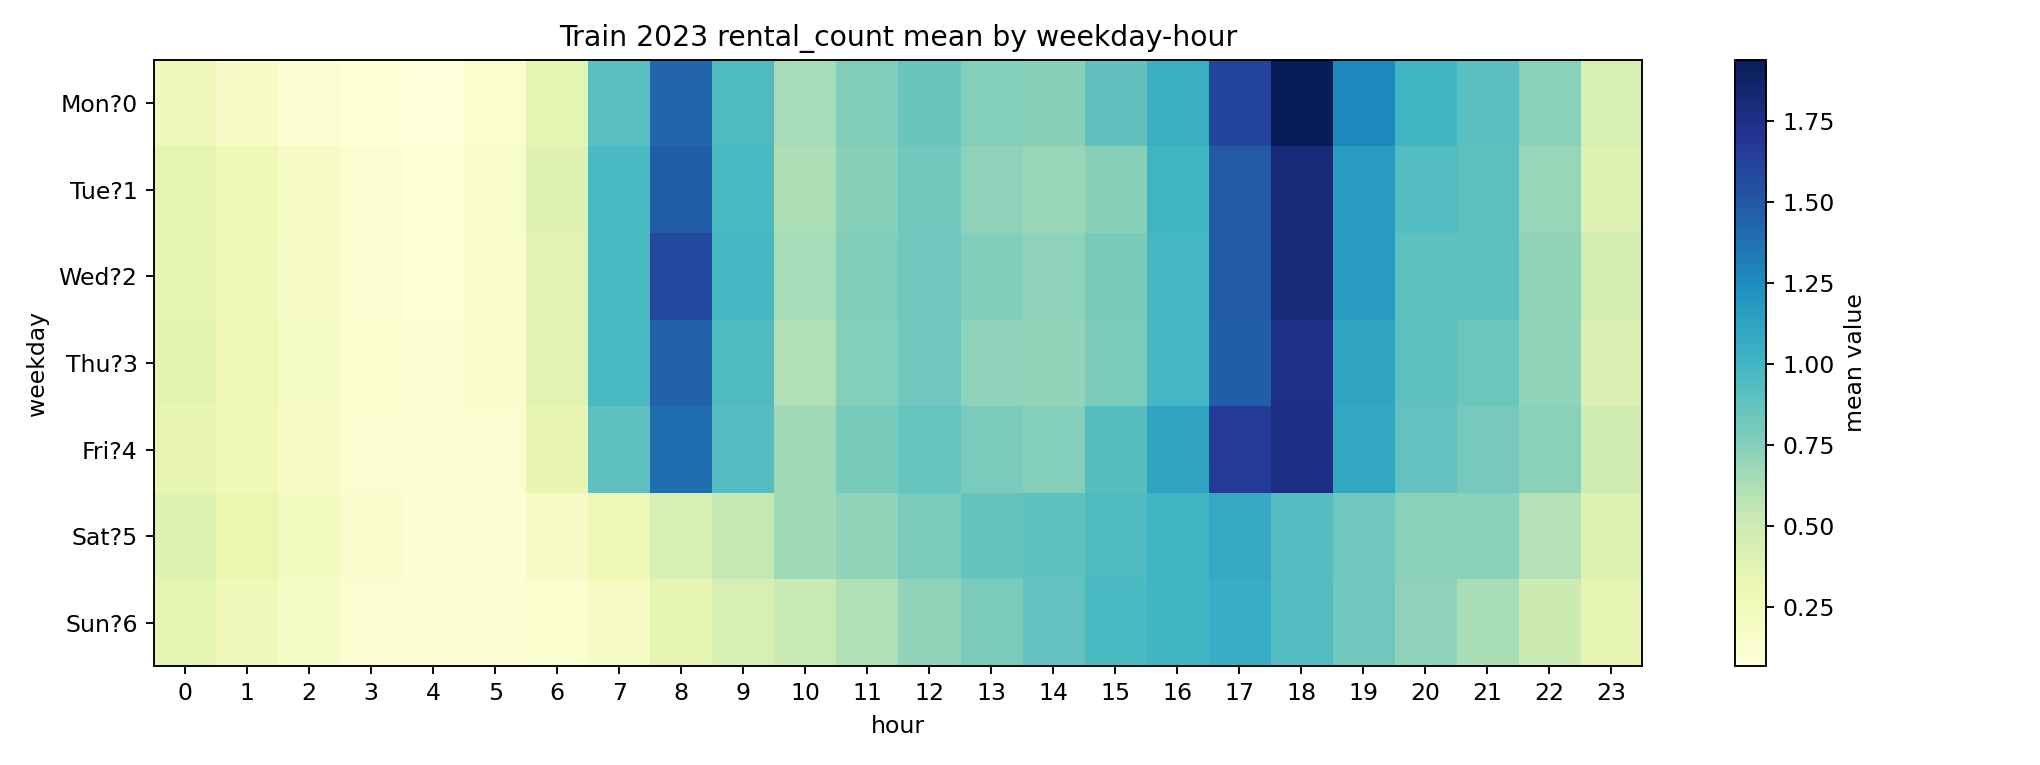

#### 02_train2023_bike_change_raw_heatmap.png

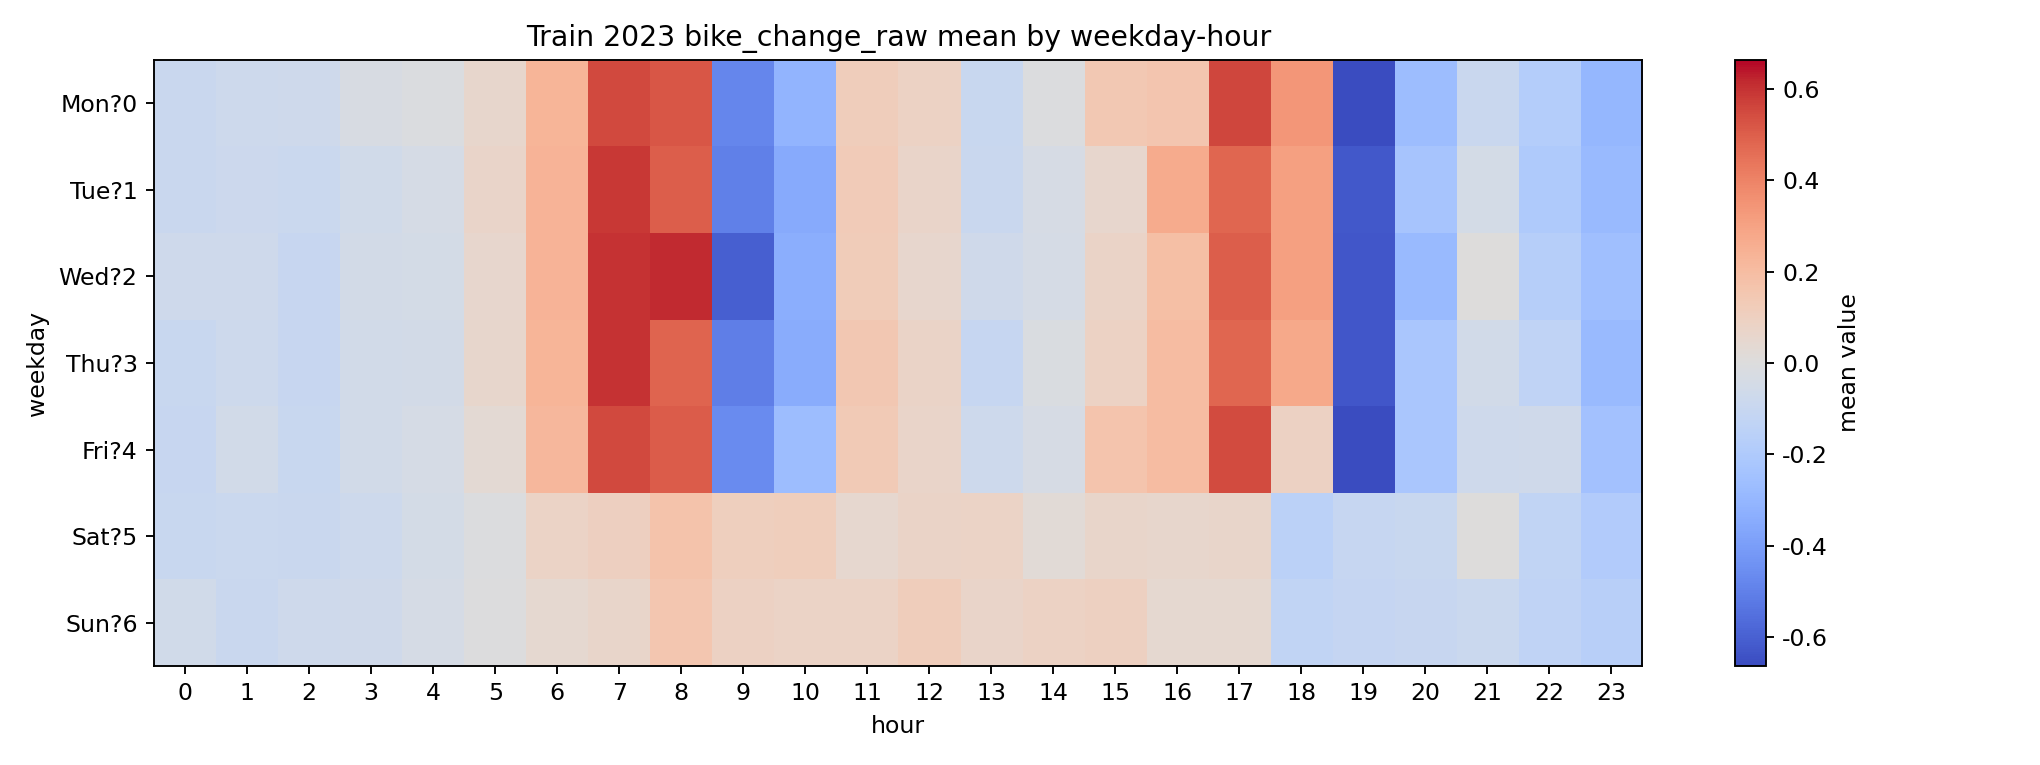

#### 03_train2023_bike_change_deseason_heatmap.png

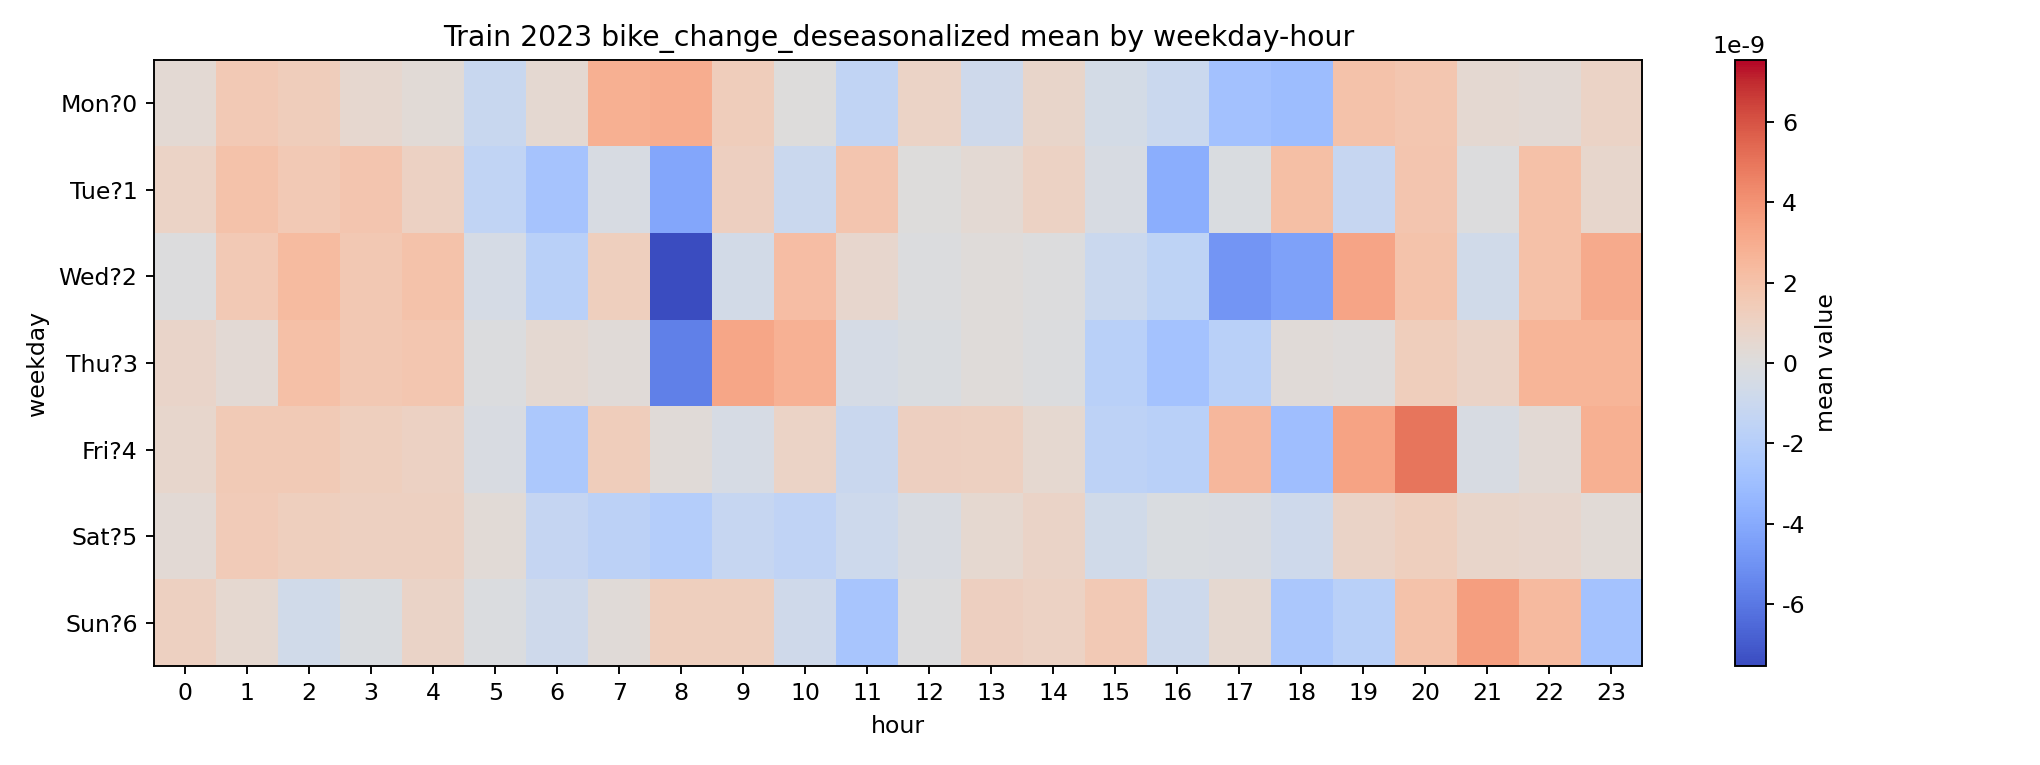

#### 04_valid2024_bike_change_raw_heatmap.png

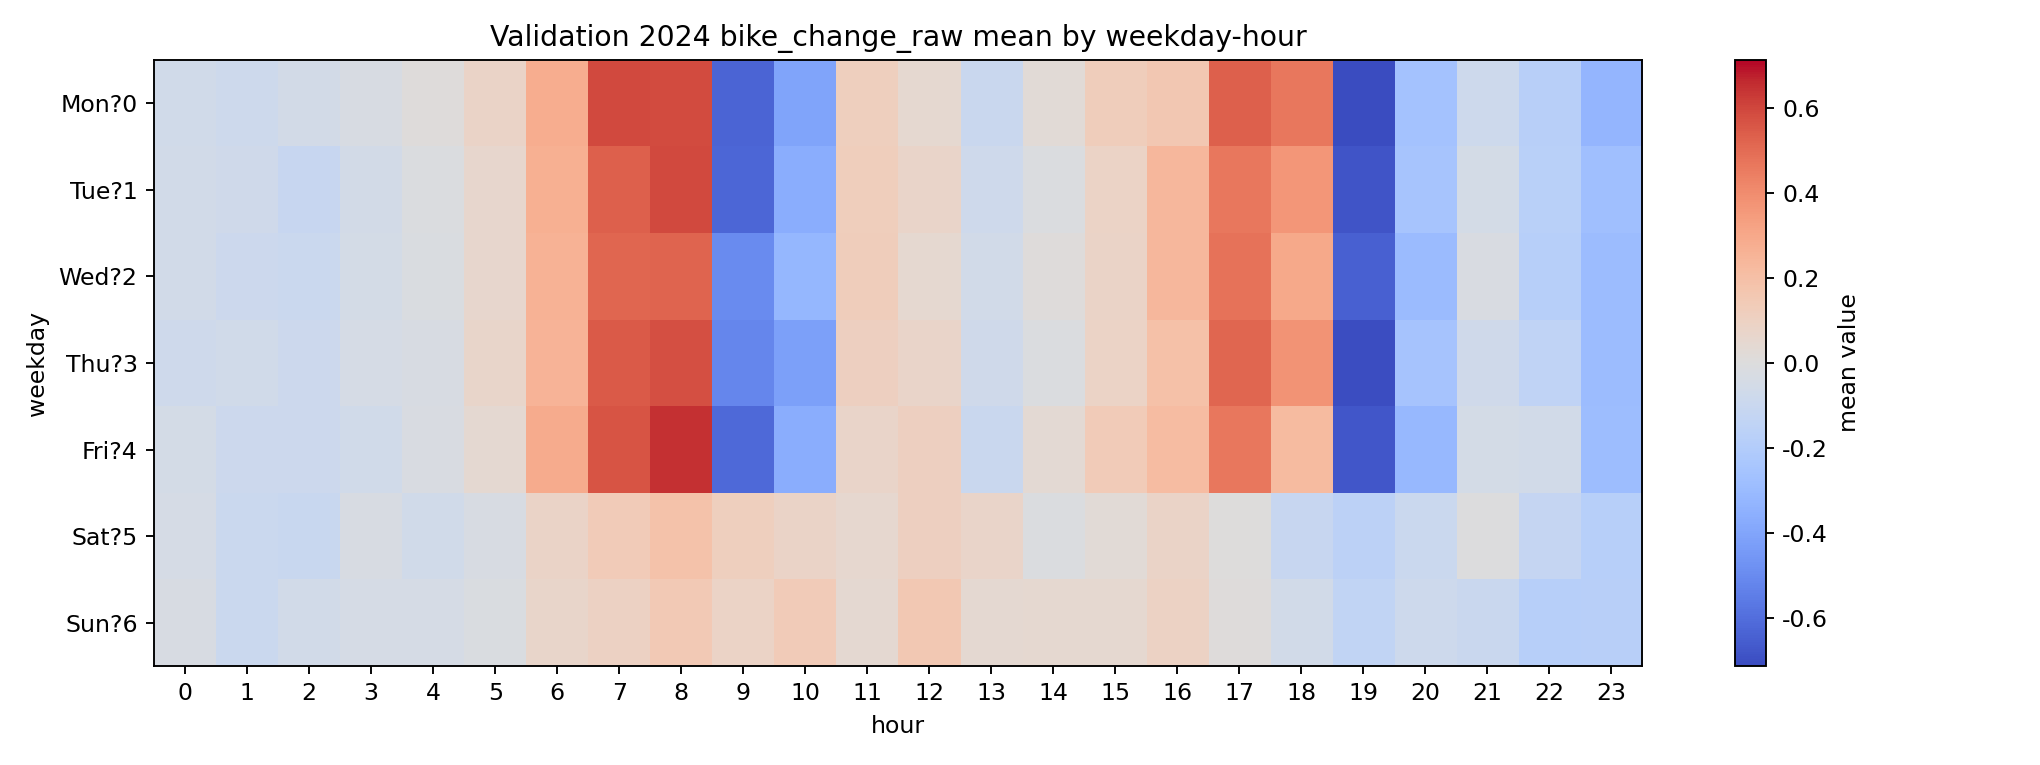

#### 05_valid2024_bike_change_deseason_heatmap.png

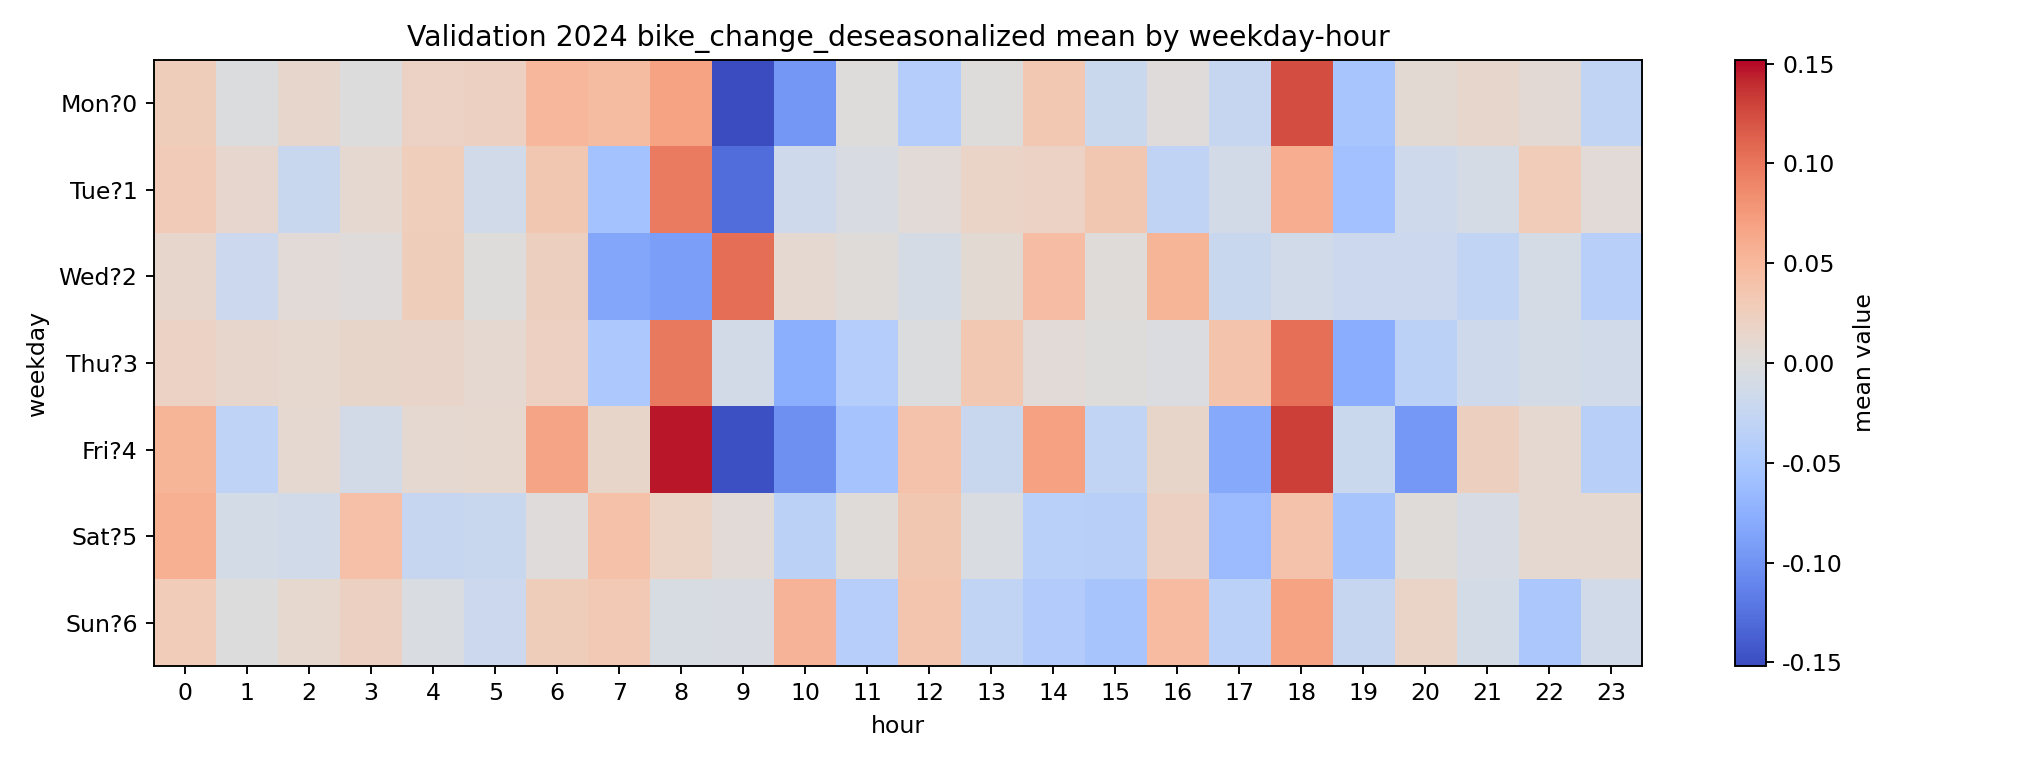

#### 06_test2025_bike_change_raw_heatmap.png

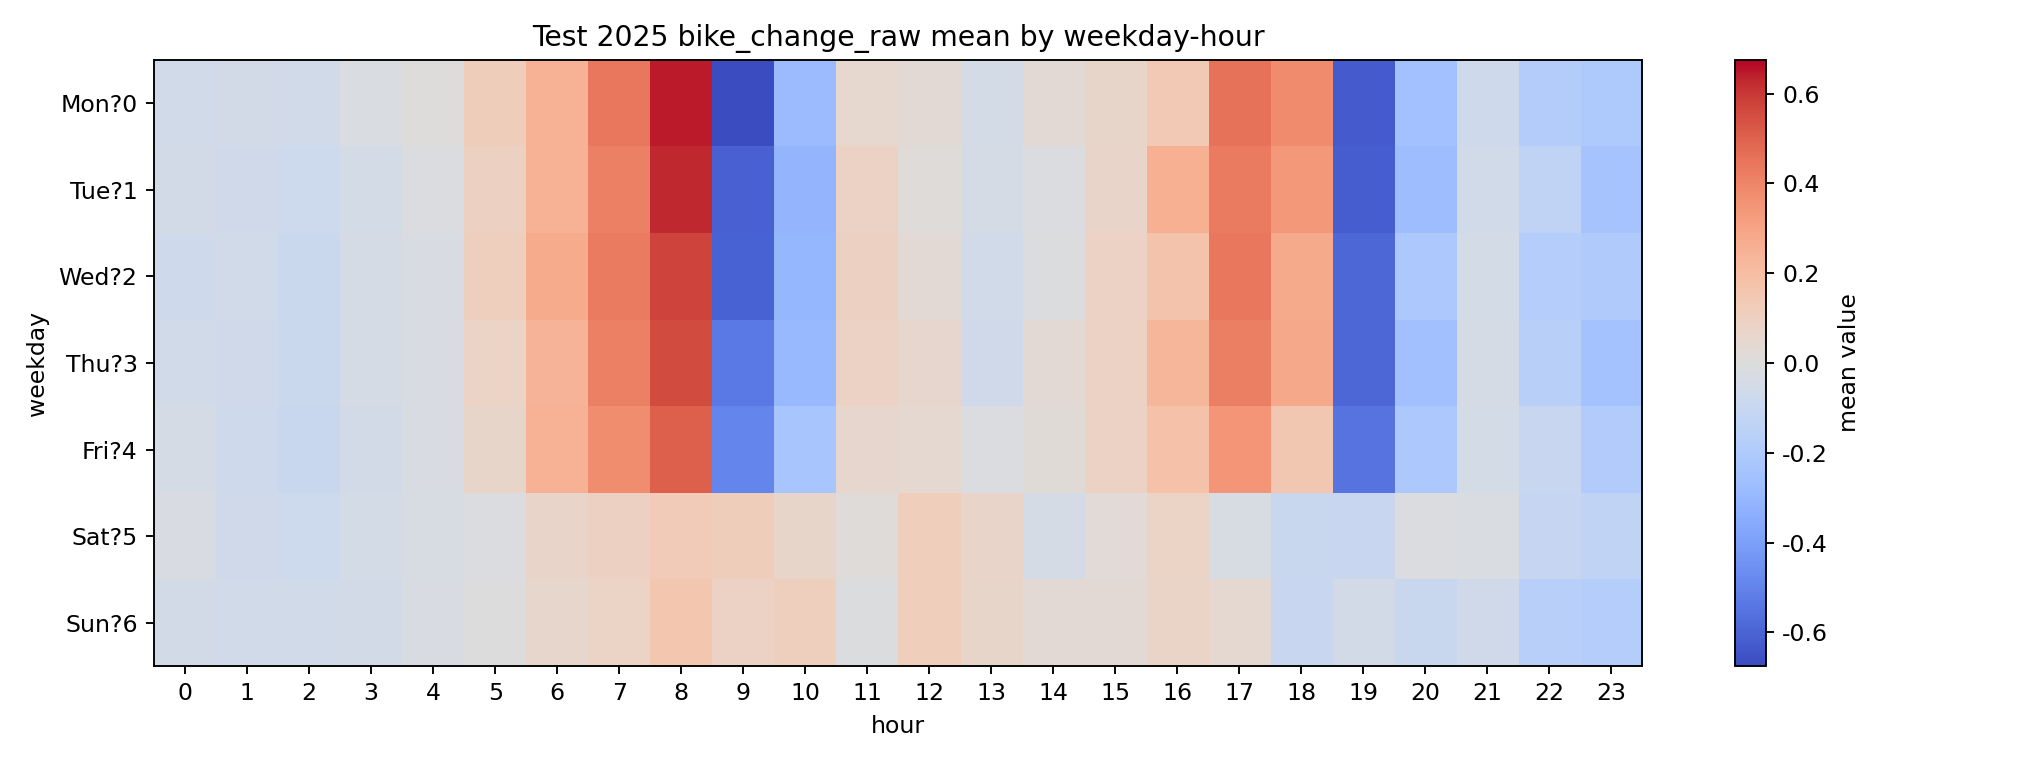

#### 07_test2025_bike_change_deseason_heatmap.png

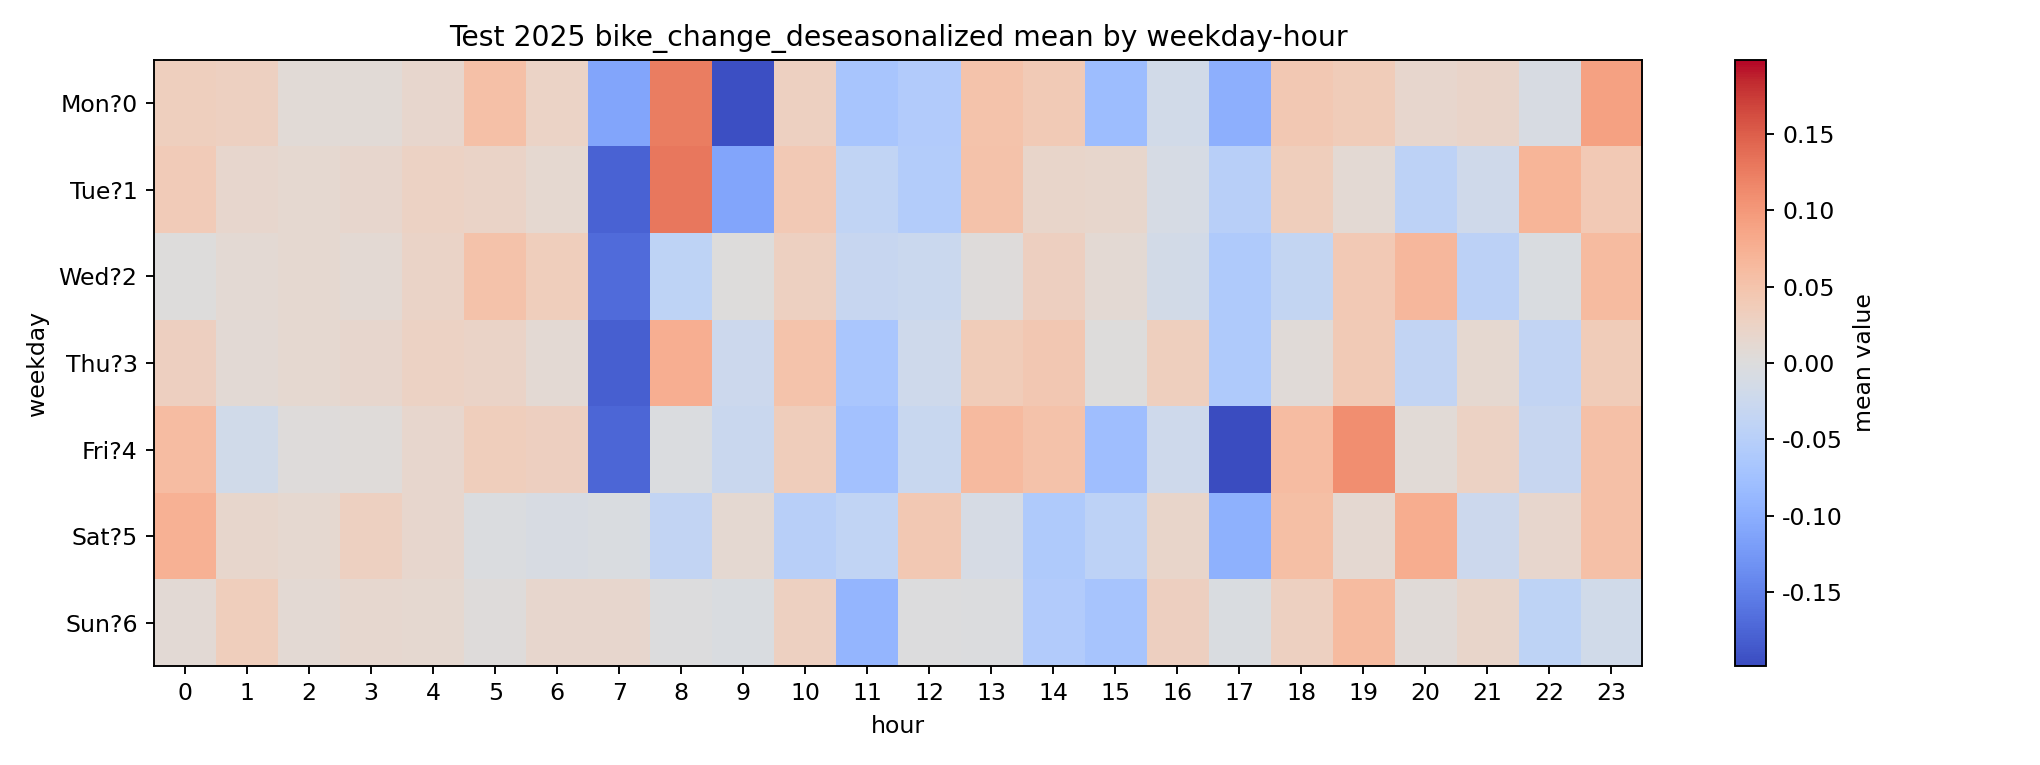

In [3]:
train_2023_rental = heatmap_df(train_2023, 'rental_count')
train_2023_raw = heatmap_df(train_2023, 'bike_change_raw')
train_2023_deseason = heatmap_df(train_2023, 'bike_change_deseasonalized')
valid_2024_raw = heatmap_df(valid_2024, 'bike_change_raw')
valid_2024_deseason = heatmap_df(valid_2024, 'bike_change_deseasonalized')
test_2025_raw = heatmap_df(test_df, 'bike_change_raw')
test_2025_deseason = heatmap_df(test_df, 'bike_change_deseasonalized')

save_heatmap(train_2023_rental, 'Train 2023 rental_count mean by weekday-hour', evidence_dir / '01_train2023_rental_count_heatmap.png', cmap='YlGnBu')
save_heatmap(train_2023_raw, 'Train 2023 bike_change_raw mean by weekday-hour', evidence_dir / '02_train2023_bike_change_raw_heatmap.png', center=0)
save_heatmap(train_2023_deseason, 'Train 2023 bike_change_deseasonalized mean by weekday-hour', evidence_dir / '03_train2023_bike_change_deseason_heatmap.png', center=0)
save_heatmap(valid_2024_raw, 'Validation 2024 bike_change_raw mean by weekday-hour', evidence_dir / '04_valid2024_bike_change_raw_heatmap.png', center=0)
save_heatmap(valid_2024_deseason, 'Validation 2024 bike_change_deseasonalized mean by weekday-hour', evidence_dir / '05_valid2024_bike_change_deseason_heatmap.png', center=0)
save_heatmap(test_2025_raw, 'Test 2025 bike_change_raw mean by weekday-hour', evidence_dir / '06_test2025_bike_change_raw_heatmap.png', center=0)
save_heatmap(test_2025_deseason, 'Test 2025 bike_change_deseasonalized mean by weekday-hour', evidence_dir / '07_test2025_bike_change_deseason_heatmap.png', center=0)

display(Markdown('### 저장된 전체 heatmap'))
for name in [
    '01_train2023_rental_count_heatmap.png',
    '02_train2023_bike_change_raw_heatmap.png',
    '03_train2023_bike_change_deseason_heatmap.png',
    '04_valid2024_bike_change_raw_heatmap.png',
    '05_valid2024_bike_change_deseason_heatmap.png',
    '06_test2025_bike_change_raw_heatmap.png',
    '07_test2025_bike_change_deseason_heatmap.png',
]:
    display(Markdown(f'#### {name}'))
    display(Image(filename=str(evidence_dir / name)))


In [4]:
station_mean = train_2023.groupby('station_id')['rental_count'].mean().sort_values(ascending=False)
sample_station_ids = [int(station_mean.index[0]), int(station_mean.index[len(station_mean)//2]), int(station_mean.index[-1])]
sample_station_ids


[2377, 2329, 2391]

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


### station 2377

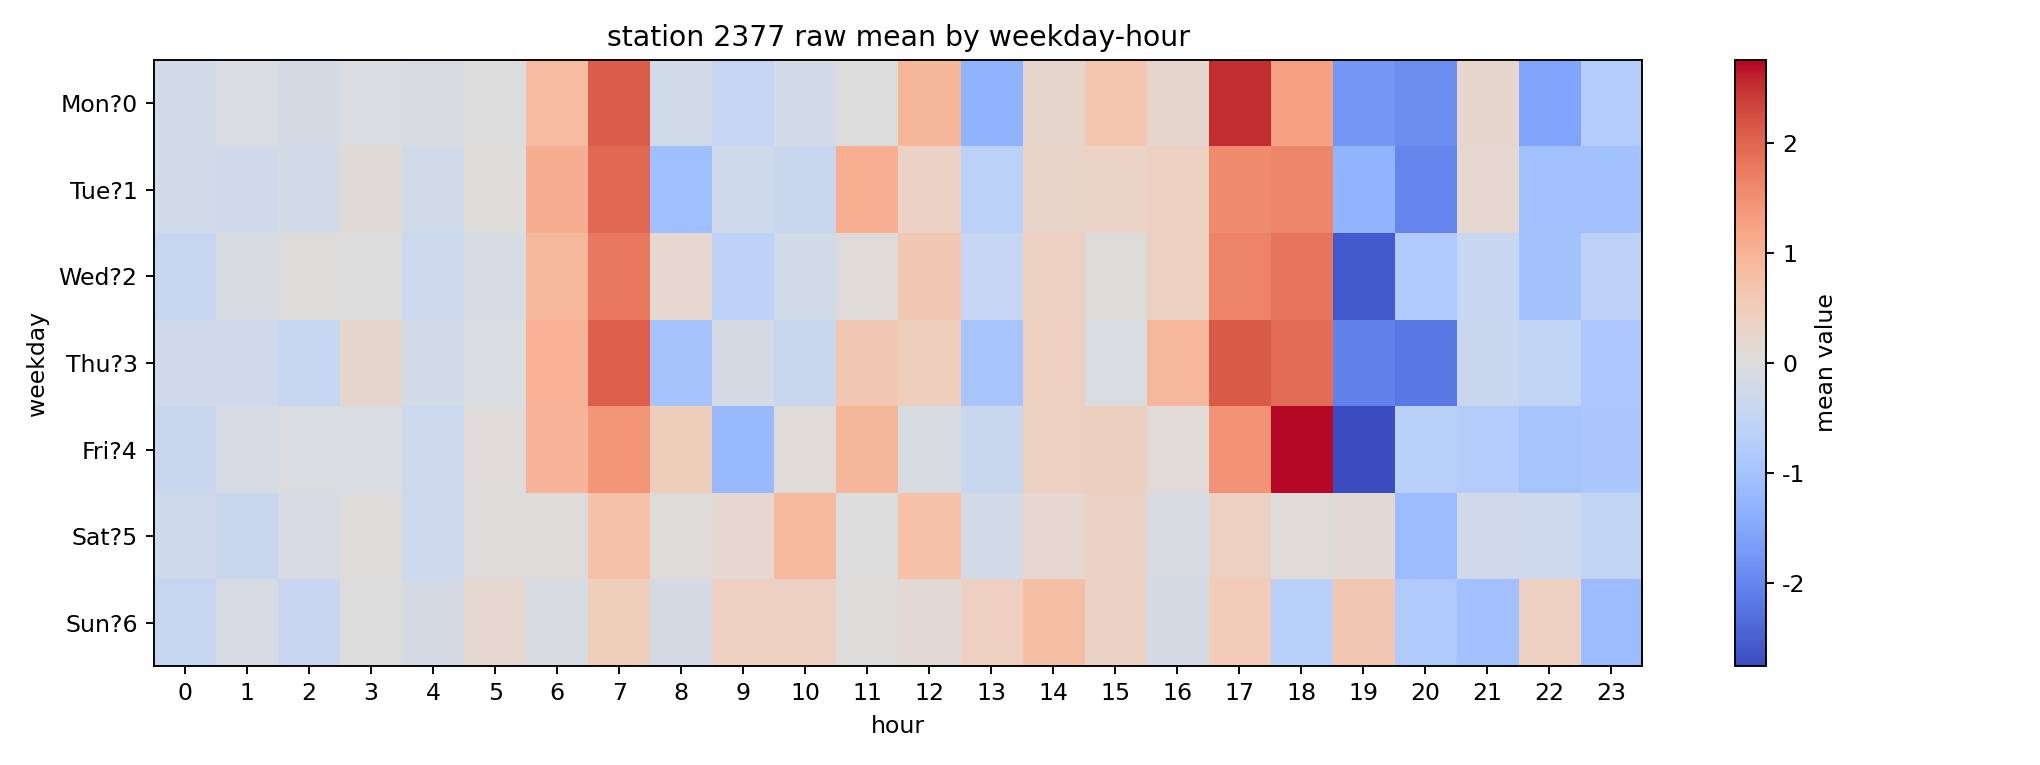

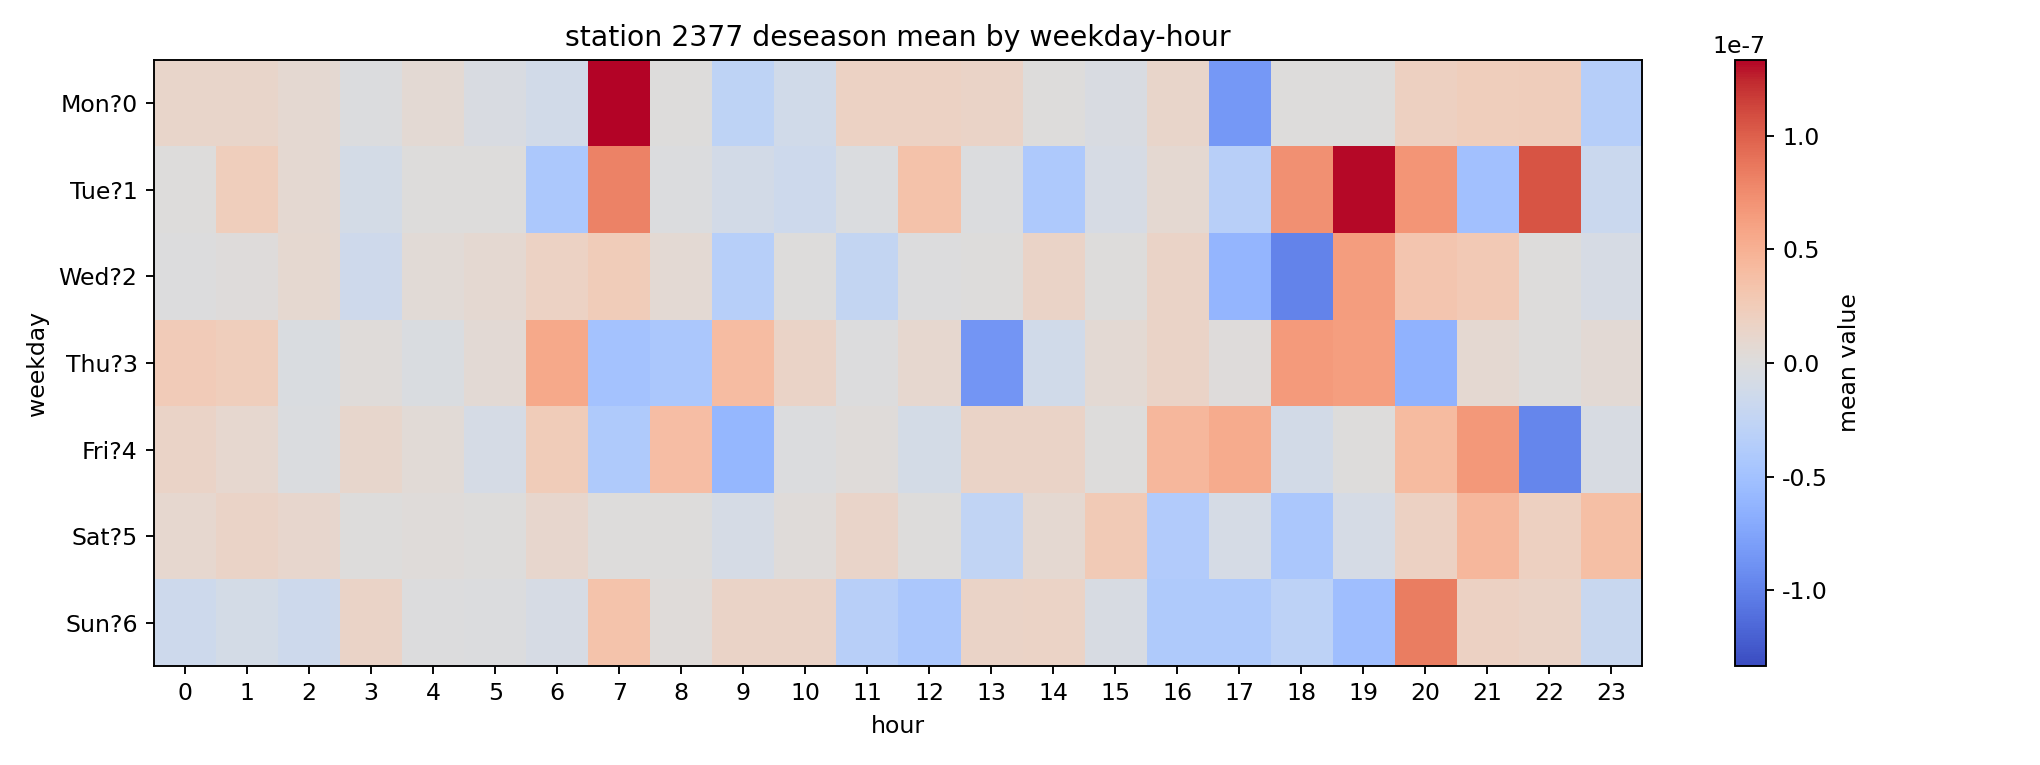

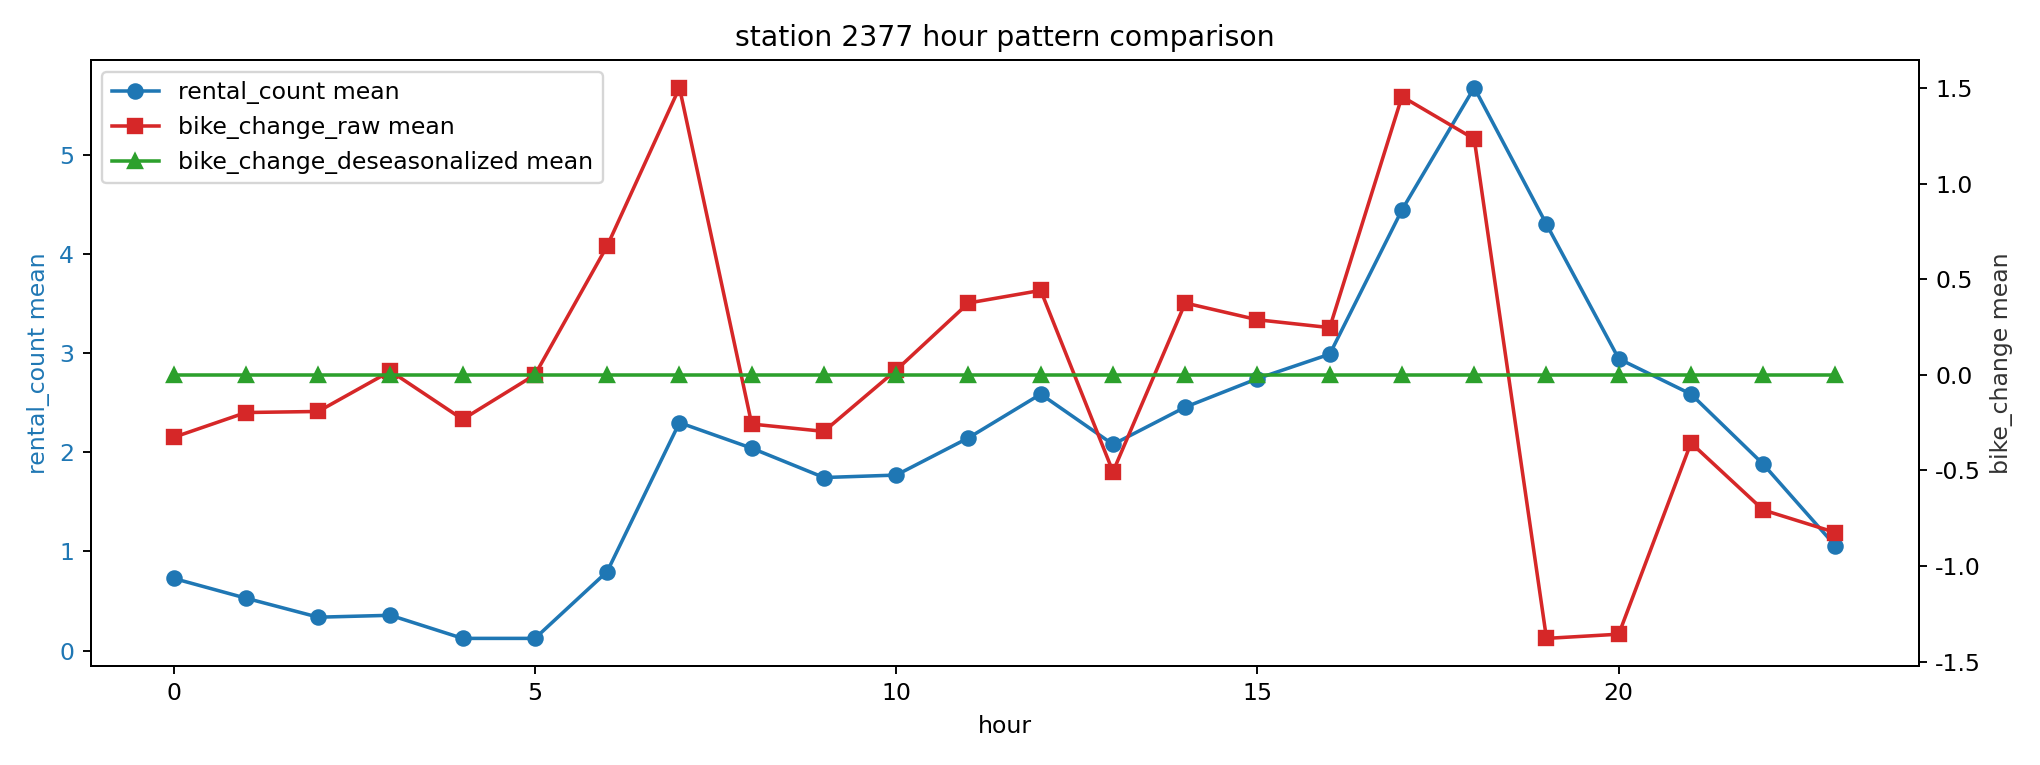

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


### station 2329

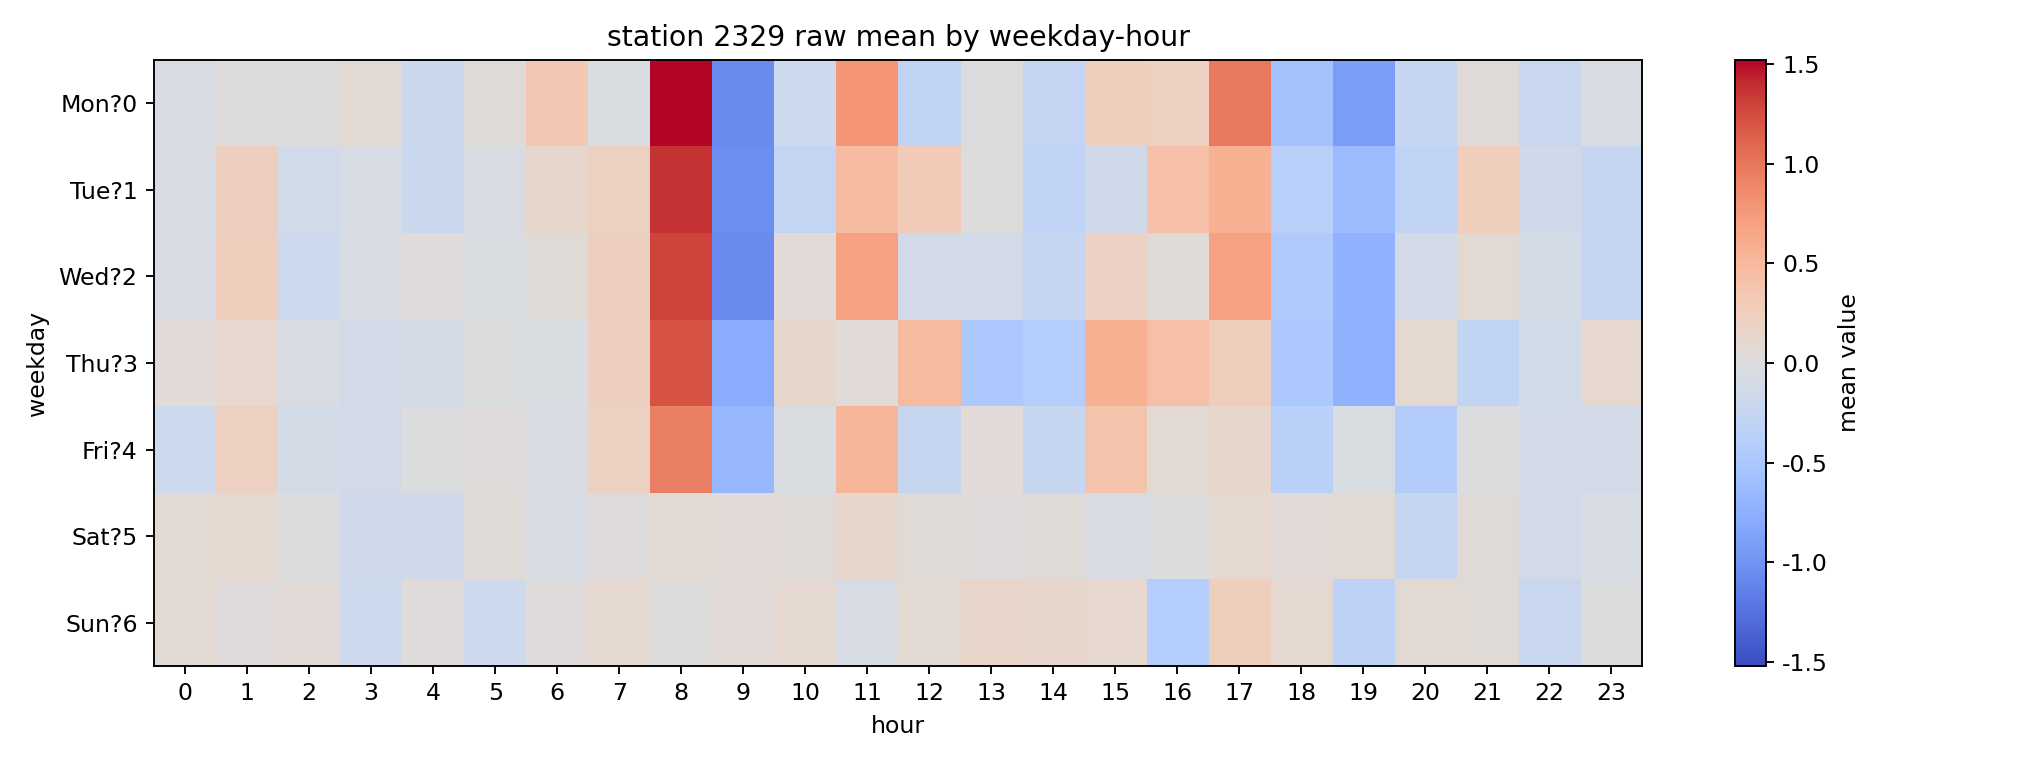

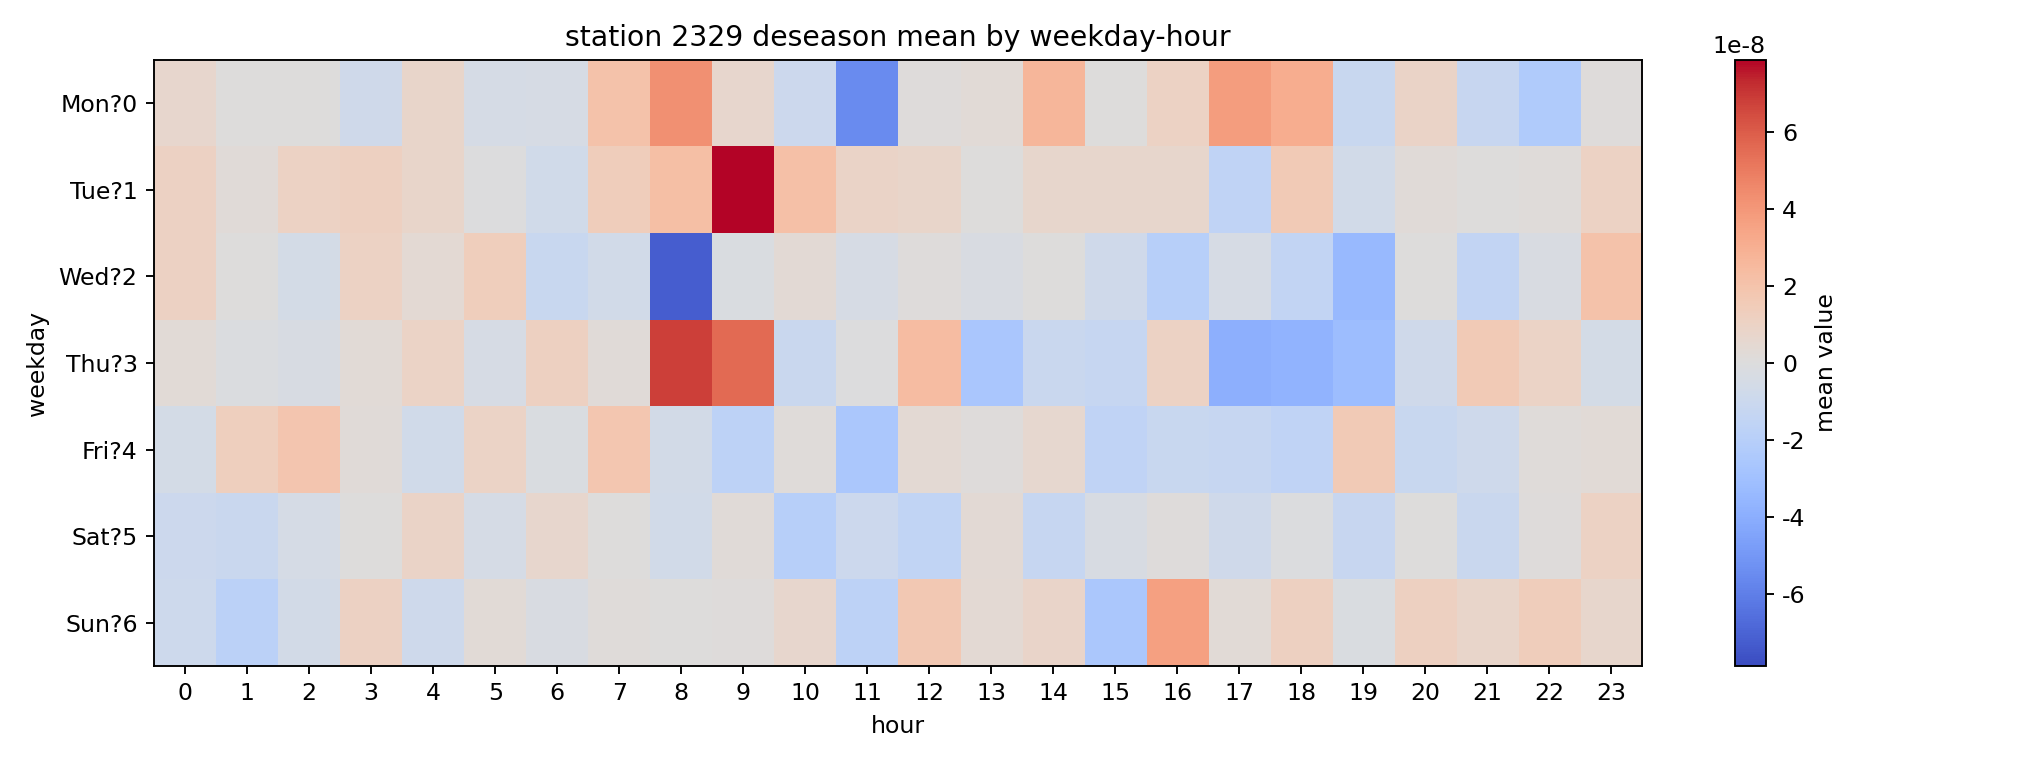

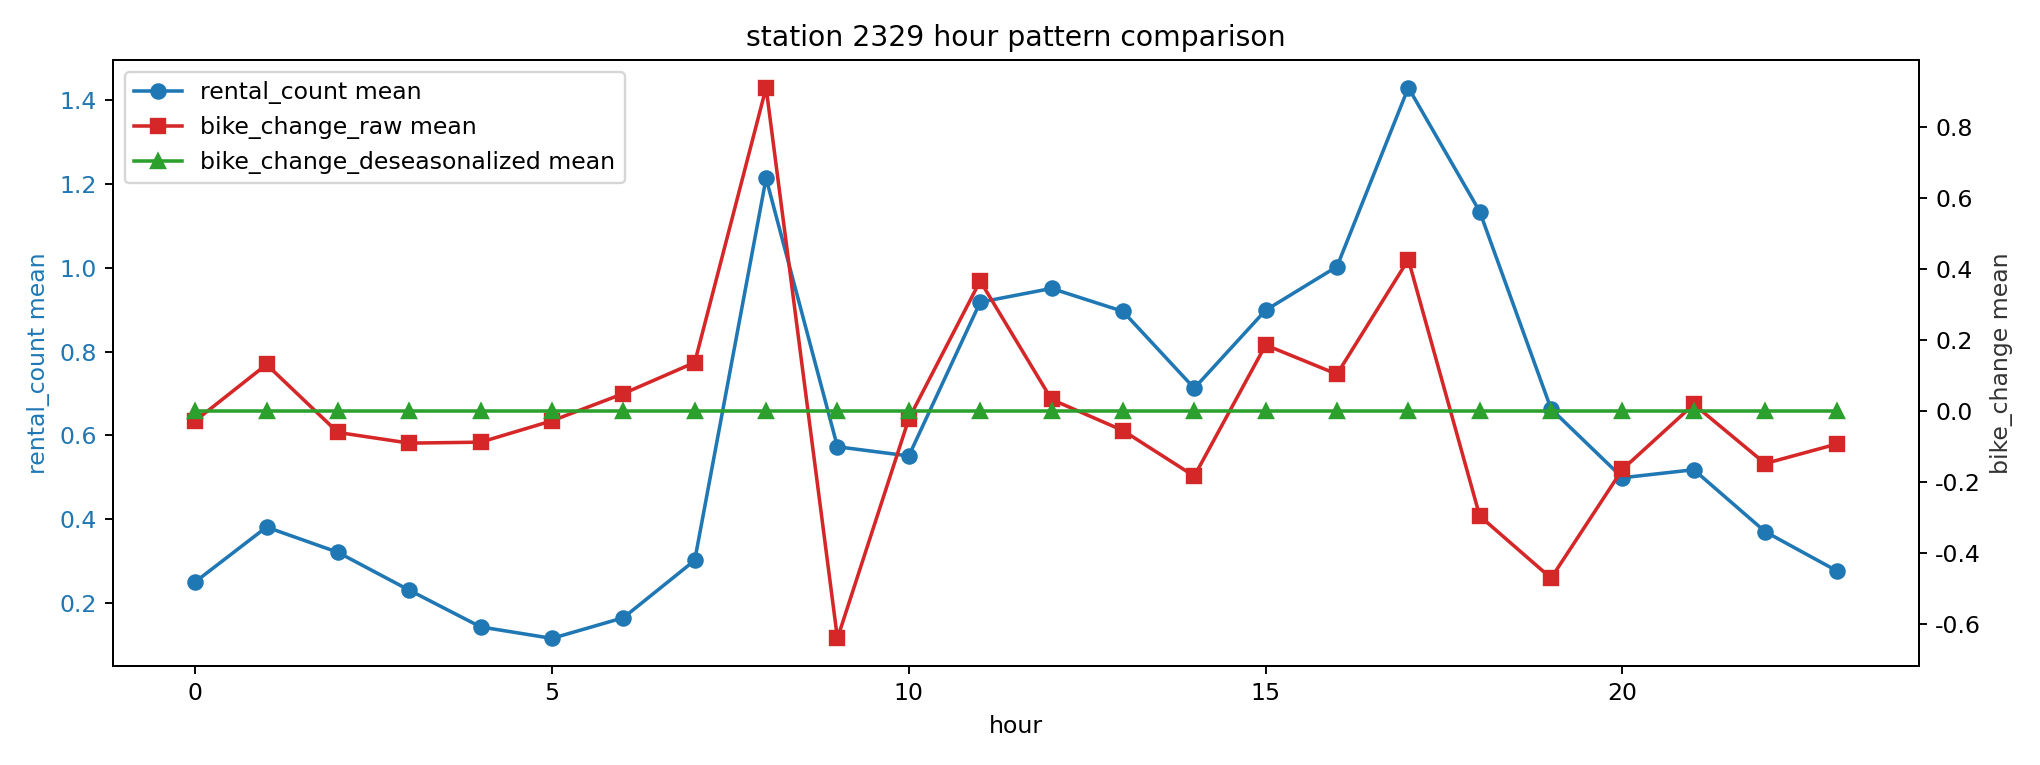

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


### station 2391

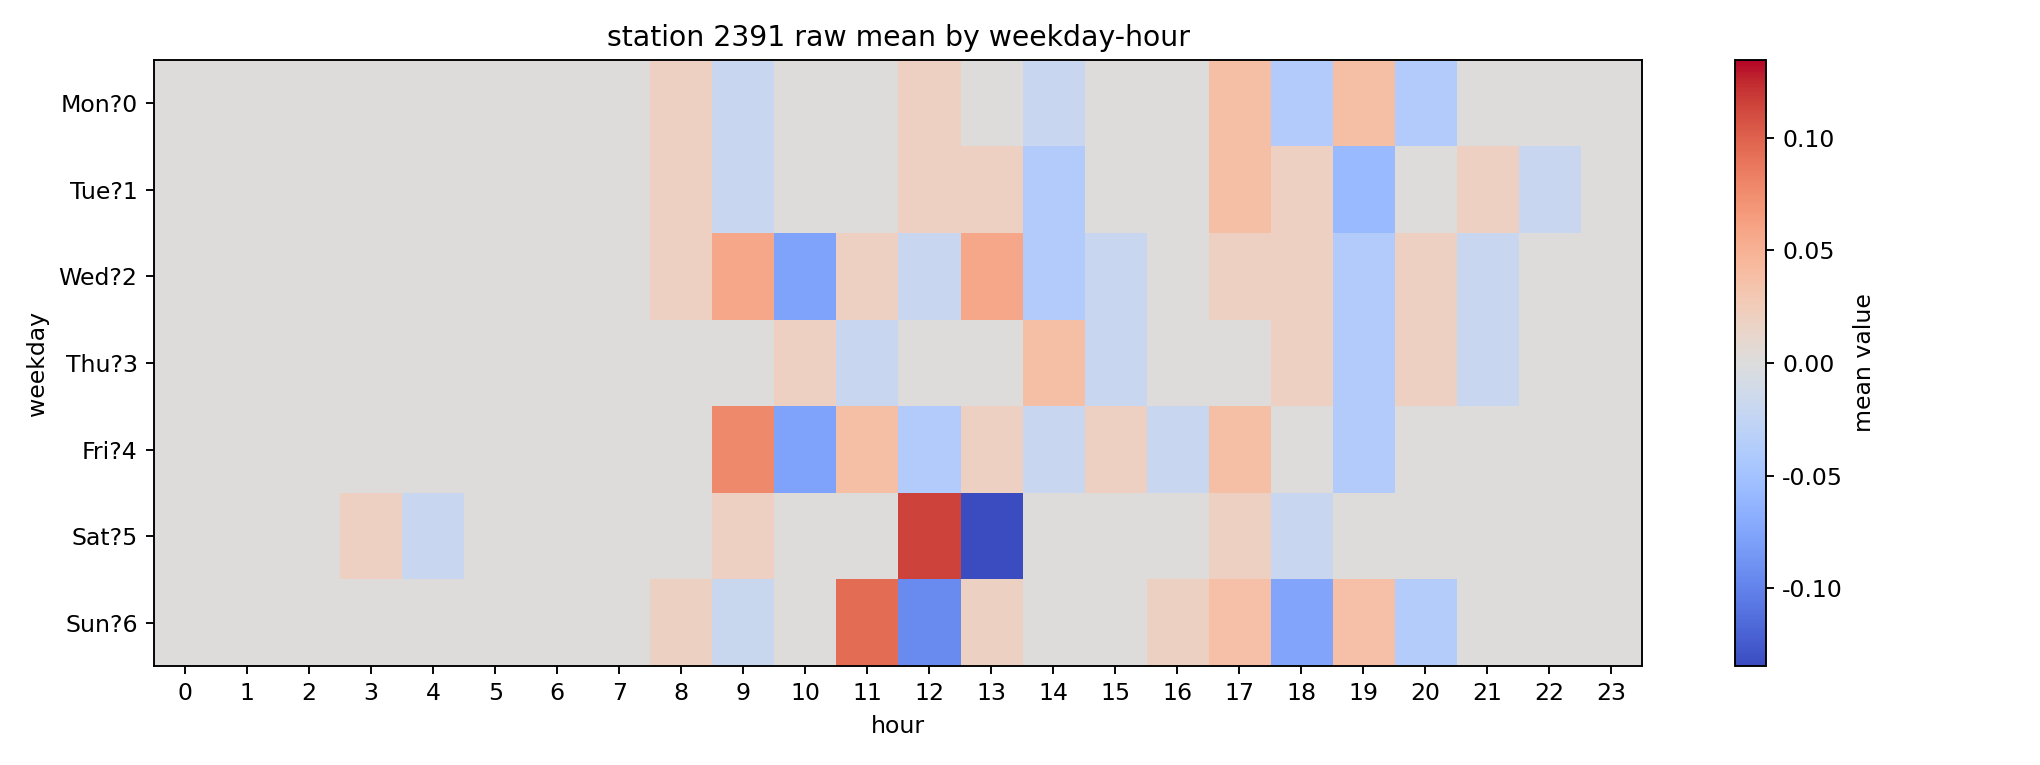

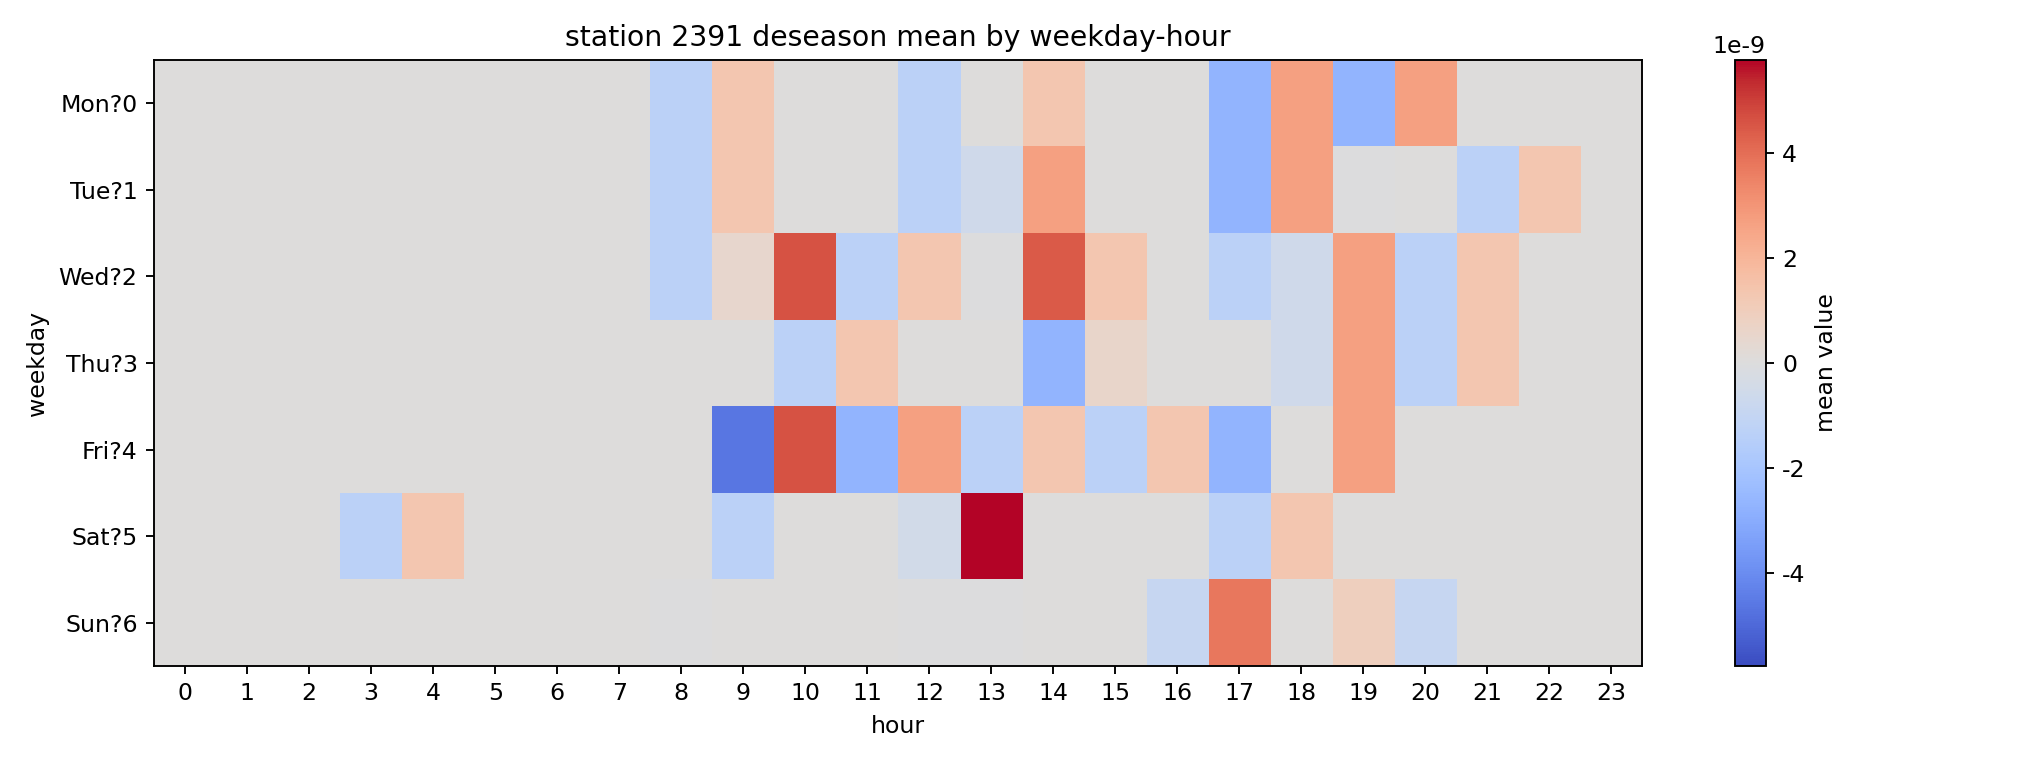

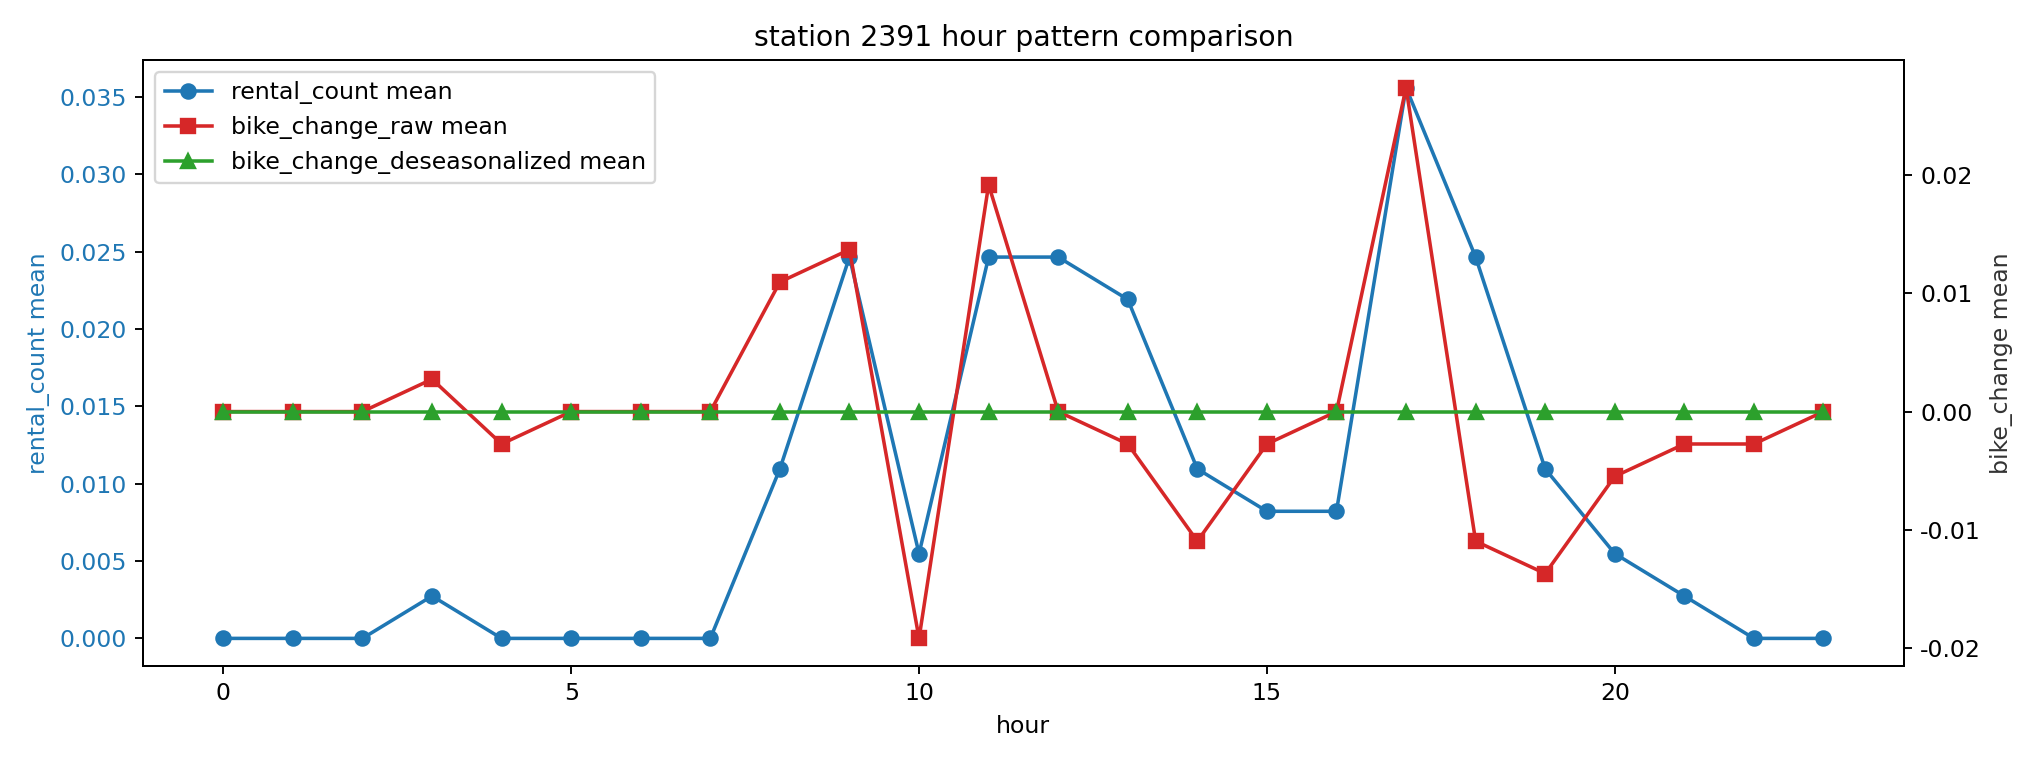

In [5]:
for rank, station_id in enumerate(sample_station_ids, start=1):
    raw_path = evidence_dir / f'10_station_{rank}_{station_id}_raw_heatmap.png'
    de_path = evidence_dir / f'11_station_{rank}_{station_id}_deseason_heatmap.png'
    overlay_path = evidence_dir / f'12_station_{rank}_{station_id}_hour_overlay.png'
    save_heatmap(station_heatmap_df(train_2023, station_id, 'bike_change_raw'), f'station {station_id} raw mean by weekday-hour', raw_path, center=0)
    save_heatmap(station_heatmap_df(train_2023, station_id, 'bike_change_deseasonalized'), f'station {station_id} deseason mean by weekday-hour', de_path, center=0)
    save_overlay_by_hour(train_2023, station_id, overlay_path)
    display(Markdown(f'### station {station_id}'))
    display(Image(filename=str(raw_path)))
    display(Image(filename=str(de_path)))
    display(Image(filename=str(overlay_path)))


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


### 분포 비교

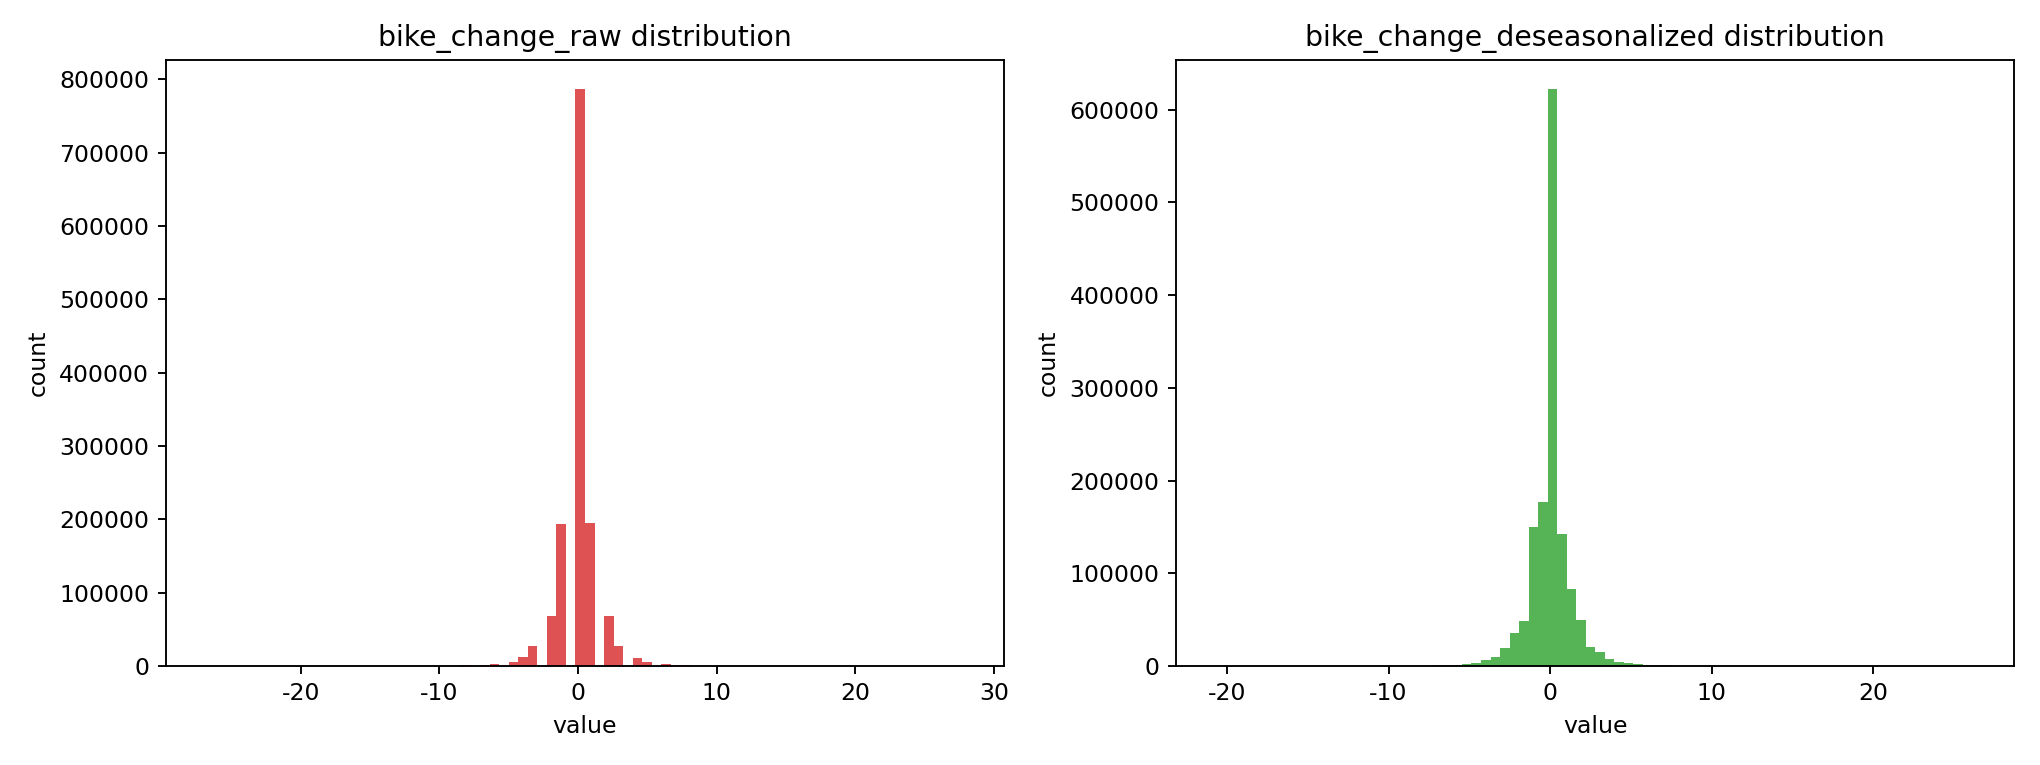

### 패턴 제거 요약표

,split,raw_abs_weekday_hour_mean,deseason_abs_weekday_hour_mean,raw_std,deseason_std,weekday_hour_abs_mean_reduction
0,train_2023,0.182055,1.365255e-09,1.388800,1.298283,0.182055
1,validation_2024,0.189956,3.235016e-02,1.390347,1.335022,0.157606
2,test_2025,0.164564,3.928451e-02,1.244436,1.215159,0.125279


In [6]:
dist_path = evidence_dir / '20_distribution_compare_raw_vs_deseason.png'
save_distribution_compare(train_2023, dist_path)
display(Markdown('### 분포 비교'))
display(Image(filename=str(dist_path)))

comparison_df = pd.DataFrame({
    'split': ['train_2023', 'validation_2024', 'test_2025'],
    'raw_abs_weekday_hour_mean': [
        float(train_2023.groupby(['weekday','hour'])['bike_change_raw'].mean().abs().mean()),
        float(valid_2024.groupby(['weekday','hour'])['bike_change_raw'].mean().abs().mean()),
        float(test_df.groupby(['weekday','hour'])['bike_change_raw'].mean().abs().mean()),
    ],
    'deseason_abs_weekday_hour_mean': [
        float(train_2023.groupby(['weekday','hour'])['bike_change_deseasonalized'].mean().abs().mean()),
        float(valid_2024.groupby(['weekday','hour'])['bike_change_deseasonalized'].mean().abs().mean()),
        float(test_df.groupby(['weekday','hour'])['bike_change_deseasonalized'].mean().abs().mean()),
    ],
    'raw_std': [
        float(train_2023['bike_change_raw'].std()),
        float(valid_2024['bike_change_raw'].std()),
        float(test_df['bike_change_raw'].std()),
    ],
    'deseason_std': [
        float(train_2023['bike_change_deseasonalized'].std()),
        float(valid_2024['bike_change_deseasonalized'].std()),
        float(test_df['bike_change_deseasonalized'].std()),
    ],
})
comparison_df['weekday_hour_abs_mean_reduction'] = comparison_df['raw_abs_weekday_hour_mean'] - comparison_df['deseason_abs_weekday_hour_mean']
comparison_path = evidence_dir / '30_pattern_reduction_summary.csv'
comparison_df.to_csv(comparison_path, index=False, encoding='utf-8-sig')
display(Markdown('### 패턴 제거 요약표'))
display(comparison_df)


## 해석 가이드

- `bike_change_raw` heatmap에서 요일-시간 패턴이 진하게 보이면 반복적 시간 구조가 강하다는 뜻이다.
- `bike_change_deseasonalized` heatmap에서 같은 구조가 약해지면, seasonal mean 제거가 의도대로 작동한 것이다.
- `30_pattern_reduction_summary.csv`에서 `weekday_hour_abs_mean_reduction`이 양수이면, 평균적인 반복 패턴 강도가 줄어든 것이다.
- station별 overlay 차트는 정제가 특정 몇 개 대여소에만 국한된 현상이 아닌지 확인하는 근거로 사용한다.
